# Computing correlations between extracted features to remove highly correlated ones

Using EEG features to start with (SW density and EMG/EOG features can still be added)

In [21]:
import numpy as np

In [ ]:
"""
Extracting EEG and Hypnogram features - so far:
Hypnogram: SPT (sleep period time), WASO (wake after sleep onset), TST (total sleep time), REM latency, SME (sleep maintenance efficiency), sleep fragmentation index, and amount of each sleep stage and proportion of TST
EEG: band powers for each stage and channel (delta, theta, alpha, sigma, beta, total abs power)
"""

import mne
import glob
import yasa
import pandas as pd

EPOCH_DURATION = 30.0
EEG_CHANNELS   = ['EEG Fpz-Cz', 'EEG Pz-Oz']
STAGE_MAP      = {0: 'W', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'R', -1: 'Uns'}

# load file paths
# define path to the data
# ADAPT THIS PATH TO WHERE YOU HAVE THE DATA
data_path = "/data"

folder_path = "sleep-edfx/1.0.0"
sc = "sleep-cassette"
st = "sleep-telemetry"

sc_paths = sorted(glob.glob(f"{data_path}/{folder_path}/{sc}/preprocessed/*.fif"))
st_paths = sorted(glob.glob(f"{data_path}/{folder_path}/{st}/preprocessed/*.fif"))

datasets = {'sc': sc_paths, 'st': st_paths}

all_dfs = []

for dataset_name, paths in datasets.items():
    for path in paths:

        # load raw objects
        raw = mne.io.read_raw_fif(path, preload=True, verbose='ERROR')
        eeg = raw.copy().pick_channels(EEG_CHANNELS)
        eeg.load_data()

        # build hypnogram
        hypno = eeg.annotations.description
        hyp = yasa.Hypnogram.from_integers(hypno, mapping=STAGE_MAP, n_stages=5, freq='30s')

        # compute bandpowers
        bp = yasa.bandpower(data=eeg, hypno=hyp, include=(0, 1, 2, 3, 4))
        bp = bp.drop(columns=["FreqRes", "Relative"])
        bp = bp.reset_index()

        # convert format into one row
        melted = bp.melt(id_vars=["Stage", "Chan"], var_name="Band", value_name="Value")
        melted['Feature'] = (
            melted['Chan'].astype(str) + '_' +
            melted['Stage'].astype(str) + '_' +
            melted['Band']
        )
        single_row = melted.pivot_table(index=None, columns='Feature', values='Value', aggfunc='first')
        single_row = single_row.reset_index(drop=True)

        sleep_stats = pd.DataFrame(hyp.sleep_statistics(), index=[0])
        sleep_stats = sleep_stats.drop(columns=["TIB", "SOL", "SOL_5min", "SE"])

        # Combine into one row
        sample = pd.concat([single_row, sleep_stats], axis=1)
        sample["dataset"] = dataset_name
        sample["file"] = path

        all_dfs.append(sample)

df = pd.concat(all_dfs, ignore_index=True)
df = df.drop(columns=['UNS'])

hyp_features = [col for col in df.columns if col in sleep_stats.columns.tolist()]
meta_cols = ['dataset', 'file']
signal_features = [col for col in df.columns if col not in hyp_features and col not in meta_cols]

print(df)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy functi

In [11]:
df

,EEG Fpz-Cz_0_Alpha,EEG Fpz-Cz_0_Beta,EEG Fpz-Cz_0_Delta,EEG Fpz-Cz_0_Gamma,EEG Fpz-Cz_0_Sigma,EEG Fpz-Cz_0_Theta,EEG Fpz-Cz_0_TotalAbsPow,EEG Fpz-Cz_1_Alpha,EEG Fpz-Cz_1_Beta,EEG Fpz-Cz_1_Delta,...,N1,N2,N3,REM,%N1,%N2,%N3,%REM,dataset,file
0,0.065376,0.031159,0.705446,0.013014,0.015420,0.169585,96.486040,0.062912,0.033877,0.667959,...,29.0,125.0,110.0,62.5,8.8821,38.2848,33.6907,19.1424,sc,/data/sleep-edfx/1.0.0/sleep-cassette/preproce...
1,0.123991,0.076347,0.501876,0.030060,0.036057,0.231669,104.874471,0.056981,0.042399,0.656781,...,29.5,186.5,148.5,107.5,6.2500,39.5127,31.4619,22.7754,sc,/data/sleep-edfx/1.0.0/sleep-cassette/preproce...
2,0.024900,0.025434,0.875024,0.007547,0.008600,0.058495,57.880545,0.037089,0.035834,0.790213,...,54.5,281.0,52.5,85.0,11.5222,59.4080,11.0994,17.9704,sc,/data/sleep-edfx/1.0.0/sleep-cassette/preproce...
3,0.029998,0.020352,0.866908,0.006435,0.008039,0.068268,82.284571,0.042276,0.039619,0.749222,...,46.0,330.0,48.0,88.0,8.9844,64.4531,9.3750,17.1875,sc,/data/sleep-edfx/1.0.0/sleep-cassette/preproce...
4,0.034776,0.029140,0.850444,0.011643,0.012658,0.061340,59.663533,0.042456,0.043798,0.765950,...,47.0,272.5,47.5,81.5,10.4794,60.7581,10.5909,18.1717,sc,/data/sleep-edfx/1.0.0/sleep-cassette/preproce...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,0.098657,0.093278,0.676409,0.022615,0.037730,0.071312,263.191276,0.102998,0.101034,0.559486,...,67.5,189.0,99.0,72.0,15.7895,44.2105,23.1579,16.8421,st,/data/sleep-edfx/1.0.0/sleep-telemetry/preproc...
193,0.179019,0.104741,0.439619,0.031685,0.053162,0.191775,69.158319,0.107186,0.044397,0.588099,...,105.5,219.0,1.0,115.5,23.9229,49.6599,0.2268,26.1905,st,/data/sleep-edfx/1.0.0/sleep-telemetry/preproc...
194,0.222309,0.108403,0.390920,0.026005,0.064567,0.187797,45.861339,0.109298,0.055336,0.584344,...,95.5,237.5,0.0,100.0,22.0554,54.8499,0.0000,23.0947,st,/data/sleep-edfx/1.0.0/sleep-telemetry/preproc...
195,0.052461,0.057843,0.738047,0.023495,0.023833,0.104322,118.493579,0.049777,0.037316,0.730012,...,21.0,335.0,22.5,118.5,4.2254,67.4044,4.5272,23.8431,st,/data/sleep-edfx/1.0.0/sleep-telemetry/preproc...


In [13]:
hypno_feature_df = df[hyp_features]
hypno_feature_df

,SPT,WASO,TST,SME,SFI,Lat_REM,WAKE,N1,N2,N3,REM,%N1,%N2,%N3,%REM
0,360.5,34.0,326.5,90.5687,0.9188,89.0,34.0,29.0,125.0,110.0,62.5,8.8821,38.2848,33.6907,19.1424
1,504.0,31.5,472.0,93.6508,1.3347,66.0,31.5,29.5,186.5,148.5,107.5,6.2500,39.5127,31.4619,22.7754
2,491.5,18.5,473.0,96.2360,0.8245,119.5,18.5,54.5,281.0,52.5,85.0,11.5222,59.4080,11.0994,17.9704
3,533.0,21.0,512.0,96.0600,0.8789,98.5,21.0,46.0,330.0,48.0,88.0,8.9844,64.4531,9.3750,17.1875
4,452.5,4.0,448.5,99.1160,0.4682,79.5,4.0,47.0,272.5,47.5,81.5,10.4794,60.7581,10.5909,18.1717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,475.5,48.0,427.5,89.9054,1.7544,78.0,48.0,67.5,189.0,99.0,72.0,15.7895,44.2105,23.1579,16.8421
193,481.5,40.5,441.0,91.5888,1.7687,81.5,40.5,105.5,219.0,1.0,115.5,23.9229,49.6599,0.2268,26.1905
194,462.0,29.0,433.0,93.7229,1.5242,59.5,29.0,95.5,237.5,0.0,100.0,22.0554,54.8499,0.0000,23.0947
195,507.5,9.0,497.0,97.9310,0.4829,98.0,9.0,21.0,335.0,22.5,118.5,4.2254,67.4044,4.5272,23.8431


In [14]:
signal_feature_df = df[signal_features]
signal_feature_df

,EEG Fpz-Cz_0_Alpha,EEG Fpz-Cz_0_Beta,EEG Fpz-Cz_0_Delta,EEG Fpz-Cz_0_Gamma,EEG Fpz-Cz_0_Sigma,EEG Fpz-Cz_0_Theta,EEG Fpz-Cz_0_TotalAbsPow,EEG Fpz-Cz_1_Alpha,EEG Fpz-Cz_1_Beta,EEG Fpz-Cz_1_Delta,...,EEG Pz-Oz_3_Sigma,EEG Pz-Oz_3_Theta,EEG Pz-Oz_3_TotalAbsPow,EEG Pz-Oz_4_Alpha,EEG Pz-Oz_4_Beta,EEG Pz-Oz_4_Delta,EEG Pz-Oz_4_Gamma,EEG Pz-Oz_4_Sigma,EEG Pz-Oz_4_Theta,EEG Pz-Oz_4_TotalAbsPow
0,0.065376,0.031159,0.705446,0.013014,0.015420,0.169585,96.486040,0.062912,0.033877,0.667959,...,0.003969,0.073594,252.710605,0.140649,0.019496,0.597182,0.005539,0.019144,0.217990,36.245701
1,0.123991,0.076347,0.501876,0.030060,0.036057,0.231669,104.874471,0.056981,0.042399,0.656781,...,0.005018,0.082749,336.401931,0.149584,0.024901,0.549589,0.005616,0.023745,0.246565,48.136231
2,0.024900,0.025434,0.875024,0.007547,0.008600,0.058495,57.880545,0.037089,0.035834,0.790213,...,0.007401,0.132445,161.238716,0.073196,0.029785,0.682137,0.007934,0.021040,0.185906,23.851016
3,0.029998,0.020352,0.866908,0.006435,0.008039,0.068268,82.284571,0.042276,0.039619,0.749222,...,0.007273,0.113954,275.622132,0.072213,0.028893,0.689754,0.008245,0.020754,0.180141,41.346129
4,0.034776,0.029140,0.850444,0.011643,0.012658,0.061340,59.663533,0.042456,0.043798,0.765950,...,0.004426,0.049420,406.219656,0.099803,0.029250,0.641009,0.005495,0.032385,0.192057,34.659514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,0.098657,0.093278,0.676409,0.022615,0.037730,0.071312,263.191276,0.102998,0.101034,0.559486,...,0.024537,0.071996,281.161055,0.159256,0.081736,0.453067,0.018240,0.049794,0.237906,37.136476
193,0.179019,0.104741,0.439619,0.031685,0.053162,0.191775,69.158319,0.107186,0.044397,0.588099,...,0.005333,0.091836,123.354408,0.187084,0.042696,0.454524,0.010446,0.057727,0.247522,19.667050
194,0.222309,0.108403,0.390920,0.026005,0.064567,0.187797,45.861339,0.109298,0.055336,0.584344,...,NaN,NaN,NaN,0.184830,0.049563,0.472966,0.012033,0.065747,0.214860,17.916307
195,0.052461,0.057843,0.738047,0.023495,0.023833,0.104322,118.493579,0.049777,0.037316,0.730012,...,0.006060,0.074776,294.266669,0.077467,0.028258,0.632238,0.006510,0.028214,0.227312,40.857263


In [17]:
all_features_df = df.drop(columns=['dataset', 'file'])

In [18]:
all_features_df

,EEG Fpz-Cz_0_Alpha,EEG Fpz-Cz_0_Beta,EEG Fpz-Cz_0_Delta,EEG Fpz-Cz_0_Gamma,EEG Fpz-Cz_0_Sigma,EEG Fpz-Cz_0_Theta,EEG Fpz-Cz_0_TotalAbsPow,EEG Fpz-Cz_1_Alpha,EEG Fpz-Cz_1_Beta,EEG Fpz-Cz_1_Delta,...,Lat_REM,WAKE,N1,N2,N3,REM,%N1,%N2,%N3,%REM
0,0.065376,0.031159,0.705446,0.013014,0.015420,0.169585,96.486040,0.062912,0.033877,0.667959,...,89.0,34.0,29.0,125.0,110.0,62.5,8.8821,38.2848,33.6907,19.1424
1,0.123991,0.076347,0.501876,0.030060,0.036057,0.231669,104.874471,0.056981,0.042399,0.656781,...,66.0,31.5,29.5,186.5,148.5,107.5,6.2500,39.5127,31.4619,22.7754
2,0.024900,0.025434,0.875024,0.007547,0.008600,0.058495,57.880545,0.037089,0.035834,0.790213,...,119.5,18.5,54.5,281.0,52.5,85.0,11.5222,59.4080,11.0994,17.9704
3,0.029998,0.020352,0.866908,0.006435,0.008039,0.068268,82.284571,0.042276,0.039619,0.749222,...,98.5,21.0,46.0,330.0,48.0,88.0,8.9844,64.4531,9.3750,17.1875
4,0.034776,0.029140,0.850444,0.011643,0.012658,0.061340,59.663533,0.042456,0.043798,0.765950,...,79.5,4.0,47.0,272.5,47.5,81.5,10.4794,60.7581,10.5909,18.1717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,0.098657,0.093278,0.676409,0.022615,0.037730,0.071312,263.191276,0.102998,0.101034,0.559486,...,78.0,48.0,67.5,189.0,99.0,72.0,15.7895,44.2105,23.1579,16.8421
193,0.179019,0.104741,0.439619,0.031685,0.053162,0.191775,69.158319,0.107186,0.044397,0.588099,...,81.5,40.5,105.5,219.0,1.0,115.5,23.9229,49.6599,0.2268,26.1905
194,0.222309,0.108403,0.390920,0.026005,0.064567,0.187797,45.861339,0.109298,0.055336,0.584344,...,59.5,29.0,95.5,237.5,0.0,100.0,22.0554,54.8499,0.0000,23.0947
195,0.052461,0.057843,0.738047,0.023495,0.023833,0.104322,118.493579,0.049777,0.037316,0.730012,...,98.0,9.0,21.0,335.0,22.5,118.5,4.2254,67.4044,4.5272,23.8431


In [19]:
corr_matrix = all_features_df.corr().abs()

In [20]:
corr_matrix

,EEG Fpz-Cz_0_Alpha,EEG Fpz-Cz_0_Beta,EEG Fpz-Cz_0_Delta,EEG Fpz-Cz_0_Gamma,EEG Fpz-Cz_0_Sigma,EEG Fpz-Cz_0_Theta,EEG Fpz-Cz_0_TotalAbsPow,EEG Fpz-Cz_1_Alpha,EEG Fpz-Cz_1_Beta,EEG Fpz-Cz_1_Delta,...,Lat_REM,WAKE,N1,N2,N3,REM,%N1,%N2,%N3,%REM
EEG Fpz-Cz_0_Alpha,1.000000,0.533870,0.825855,0.124997,0.698501,0.584833,0.359860,0.523302,0.126756,0.396290,...,0.271546,0.258924,0.026226,0.115424,0.048280,0.144494,0.007841,0.016744,0.009777,0.054016
EEG Fpz-Cz_0_Beta,0.533870,1.000000,0.849127,0.710608,0.789836,0.248922,0.239033,0.325548,0.629236,0.569912,...,0.001989,0.098984,0.079458,0.031107,0.070421,0.216906,0.091967,0.098194,0.061845,0.200861
EEG Fpz-Cz_0_Delta,0.825855,0.849127,1.000000,0.569699,0.863834,0.662074,0.341142,0.459674,0.341533,0.543559,...,0.091564,0.142834,0.047629,0.058523,0.036842,0.206395,0.068175,0.033919,0.003148,0.151669
EEG Fpz-Cz_0_Gamma,0.124997,0.710608,0.569699,1.000000,0.424372,0.138301,0.033543,0.120684,0.338783,0.327343,...,0.209757,0.152406,0.179749,0.080663,0.136475,0.162669,0.177230,0.091583,0.146447,0.186050
EEG Fpz-Cz_0_Sigma,0.698501,0.789836,0.863834,0.424372,1.000000,0.436027,0.292634,0.441004,0.306212,0.446810,...,0.131642,0.175686,0.044979,0.063430,0.016495,0.186831,0.056412,0.008540,0.034307,0.150799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
REM,0.144494,0.216906,0.206395,0.162669,0.186831,0.084230,0.181261,0.260977,0.124110,0.215898,...,0.044481,0.030661,0.223769,0.002532,0.184545,1.000000,0.324629,0.358105,0.081840,0.939464
%N1,0.007841,0.091967,0.068175,0.177230,0.056412,0.021025,0.131599,0.091354,0.038260,0.039689,...,0.112216,0.395275,0.972767,0.218945,0.506690,0.324629,1.000000,0.231809,0.497786,0.341544
%N2,0.016744,0.098194,0.033919,0.091583,0.008540,0.085393,0.029072,0.042943,0.121755,0.087772,...,0.107340,0.062364,0.241961,0.802483,0.562855,0.358105,0.231809,1.000000,0.564396,0.408685
%N3,0.009777,0.061845,0.003148,0.146447,0.034307,0.127238,0.070835,0.023952,0.010424,0.093112,...,0.171335,0.274317,0.487827,0.493719,0.975862,0.081840,0.497786,0.564396,1.000000,0.112185


In [22]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [23]:
upper

,EEG Fpz-Cz_0_Alpha,EEG Fpz-Cz_0_Beta,EEG Fpz-Cz_0_Delta,EEG Fpz-Cz_0_Gamma,EEG Fpz-Cz_0_Sigma,EEG Fpz-Cz_0_Theta,EEG Fpz-Cz_0_TotalAbsPow,EEG Fpz-Cz_1_Alpha,EEG Fpz-Cz_1_Beta,EEG Fpz-Cz_1_Delta,...,Lat_REM,WAKE,N1,N2,N3,REM,%N1,%N2,%N3,%REM
EEG Fpz-Cz_0_Alpha,NaN,0.53387,0.825855,0.124997,0.698501,0.584833,0.359860,0.523302,0.126756,0.396290,...,0.271546,0.258924,0.026226,0.115424,0.048280,0.144494,0.007841,0.016744,0.009777,0.054016
EEG Fpz-Cz_0_Beta,NaN,NaN,0.849127,0.710608,0.789836,0.248922,0.239033,0.325548,0.629236,0.569912,...,0.001989,0.098984,0.079458,0.031107,0.070421,0.216906,0.091967,0.098194,0.061845,0.200861
EEG Fpz-Cz_0_Delta,NaN,NaN,NaN,0.569699,0.863834,0.662074,0.341142,0.459674,0.341533,0.543559,...,0.091564,0.142834,0.047629,0.058523,0.036842,0.206395,0.068175,0.033919,0.003148,0.151669
EEG Fpz-Cz_0_Gamma,NaN,NaN,NaN,NaN,0.424372,0.138301,0.033543,0.120684,0.338783,0.327343,...,0.209757,0.152406,0.179749,0.080663,0.136475,0.162669,0.177230,0.091583,0.146447,0.186050
EEG Fpz-Cz_0_Sigma,NaN,NaN,NaN,NaN,NaN,0.436027,0.292634,0.441004,0.306212,0.446810,...,0.131642,0.175686,0.044979,0.063430,0.016495,0.186831,0.056412,0.008540,0.034307,0.150799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
REM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.324629,0.358105,0.081840,0.939464
%N1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.231809,0.497786,0.341544
%N2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.564396,0.408685
%N3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.112185


In [24]:
# Stack and clean
correlations = (upper.stack()
                     .reset_index()
                     .rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Correlation'}))

# Sort by absolute correlation descending
correlations = correlations.iloc[correlations['Correlation'].abs().argsort()[::-1]]

print(correlations.to_string(index=False))

               Feature 1                Feature 2  Correlation
                    WASO                     WAKE     1.000000
       EEG Pz-Oz_2_Gamma        EEG Pz-Oz_3_Gamma     0.989703
                      N3                      %N3     0.975862
                      N1                      %N1     0.972767
        EEG Pz-Oz_3_Beta        EEG Pz-Oz_3_Gamma     0.966475
       EEG Pz-Oz_2_Gamma         EEG Pz-Oz_3_Beta     0.954070
                    WASO                      SME     0.952489
                     SME                     WAKE     0.952489
                     SPT                     WASO     0.948809
                     SPT                     WAKE     0.948809
                     REM                     %REM     0.939464
      EEG Fpz-Cz_2_Sigma        EEG Pz-Oz_2_Sigma     0.935148
        EEG Pz-Oz_2_Beta         EEG Pz-Oz_3_Beta     0.932393
       EEG Pz-Oz_2_Gamma        EEG Pz-Oz_4_Gamma     0.927271
        EEG Pz-Oz_2_Beta        EEG Pz-Oz_2_Gamma     0

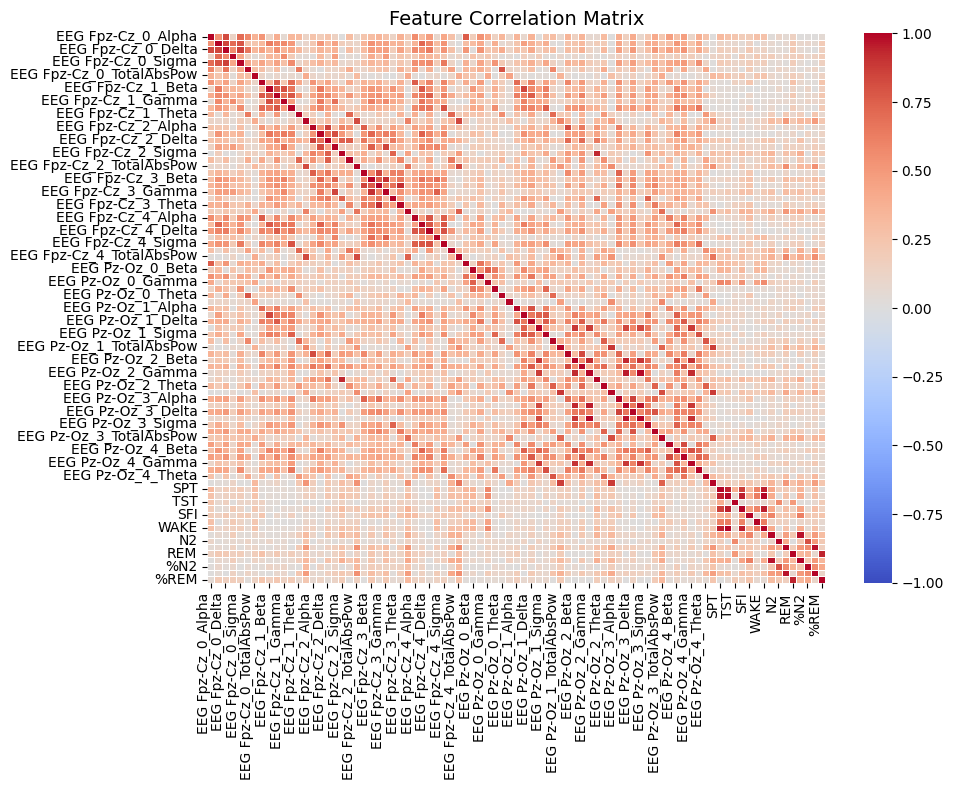

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=False,          # Show correlation values in cells
    cmap="coolwarm",     # Color scheme (blue=negative, red=positive)
    vmin=-1, vmax=1,     # Fix color scale to [-1, 1]
    linewidths=0.5,      # Add gridlines between cells
)

plt.title("Feature Correlation Matrix", fontsize=14)
plt.xticks(rotation=90, ha="right")  # Rotate x labels for readability
plt.tight_layout()
plt.show()

In [28]:
# remove highly correlated features
corr_threshold = 0.5 # need to select threshold

to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]
selected_features = [col for col in all_features_df.columns if col not in to_drop]
print("correlation filter selected:", selected_features)
print("n =", len(selected_features))

correlation filter selected: ['EEG Fpz-Cz_0_Alpha', 'EEG Fpz-Cz_0_TotalAbsPow', 'EEG Fpz-Cz_1_TotalAbsPow', 'EEG Pz-Oz_0_TotalAbsPow', 'TST', 'SFI', 'REM']
n = 7


In [ ]:
# then idea would be to cluster on: 1) hypno_features, 2) signal_features, 3) selected_features